<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Introduction to Multiple Linear Regression MLR

---

## Review


### Overview of Supervised Learning
---

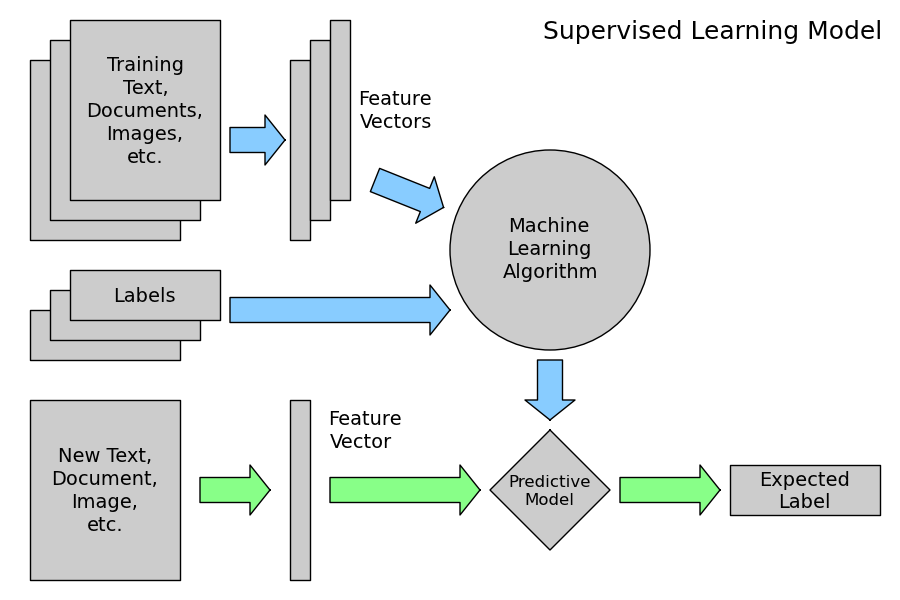
<br>
<small style="color: gray;">Source: https://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/tutorial/astronomy/general_concepts.html</small>



As we discussed in previous lecture:
_Simple linear regression (SLR) has one independent variable._

_Multivariable (MLR) has potentially infinite independent variables._



#### In either case, we are looking to minimize the difference between our predictions, $\hat{y}$, and the true value, $y$

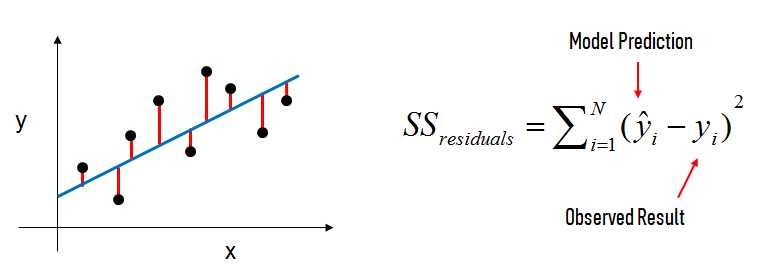

In the diagram above:

- The black dots are the **observed values** of x and y.
- The blue line is our **least squares line**.
- The red lines are the **residuals**, which are the vertical distances between the observed values and the least squares line.


### Form of Linear Regression

Simple LR uses one feature and a constant to represent a relationship with another feature.
### $y = \beta_0 + \beta_1x +\epsilon_i $ 

but you might know it as
### $ y = mx + b$

And we can extend the simple linear regression into the multiple linear regression (more on this later):
### $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon_i$

- $y$ is the response (the target/outcome/dependent variable)
- $\beta_0$ is the intercept
- $\beta_1$ is the coefficient for $x_1$ (the first feature/independent variable)
- $\beta_n$ is the coefficient for $x_n$ (the nth feature/independent)
- $\epsilon_i$ is the constant error

The $\beta$ values are called the **model coefficients**:

- These values are estimated (or "learned") during the model fitting process using the **least squares criterion**.
- Specifically, we are finding the line (mathematically) which minimizes the **sum of squared residuals** (or "sum of squared errors").
- And once we've learned these coefficients, we can use the model to predict the response and draw inferences about the relationships between variables and the outcome.



## The `sklearn` process

When we model data using `sklearn`, we're going to follow (more or less) the same process every time.

1. Select and instantiate the algorithm we want to use (i.e., `from [library] import [model]`)
2. Create a feature matrix (called 'X' for convenience) with your independent variable(s)
2. Create an outcome/targe/response matrix (usually denoted 'y') with your dependent variable
3. Ensure that X and y are the same length (.shape is your friend here)
4. Instantiate the estimator
5. Fit the estimator (i.e., train your model)
6. Use the estimator to make predictions
7. Evaluate the predictions using the appropriate metric

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
# %matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# %autosave 0

## Bikeshare Data 🚴‍♂️
Data adapted from source: [here](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)


Multiple Linear Regression (MLR) with Categorical Features

#### Goal: predict the number of riders (count), based on the features.

In [2]:
bike = pd.read_csv('./data/bikeshare.csv')

In [3]:
print(bike.shape)
bike.head()

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


### Data Dictionary

| Variable| Description |
|---------|----------------|
|datetime| hourly date + timestamp  |
|season|  1 = spring, 2 = summer, 3 = fall, 4 = winter |
|holiday| whether the day is considered a holiday|
|workingday| whether the day is neither a weekend nor holiday|
|weather| 1: Clear, 2: Mist, 3: Light Snow 4: Heavy Rain|
|temp| temperature in Celsius|
|atemp| "feels like" temperature in Celsius|
|humidity| relative humidity|
|windspeed| wind speed|
|casual| number of non-registered user rentals initiated|
|registered| number of registered user rentals initiated|
|count| number of total rentals|

## Make Quick EDA


In [4]:
# check the datatype of the columns

bike.dtypes

datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

### Some preprocessing to clean things up:
1. Rename "count" to "riders"
2. Drop "casual" and "registered"
3. Cast "datetime" to actually be a datetime


In [5]:
# Some preprocessing:
# 1 - Rename "count" column to "riders"
bike.rename(columns={'count':'riders'},inplace=True)

# 2 - Drop "casual" and "registered"
bike.drop(columns=['casual','registered'], inplace=True)

# 3 - Cast "datetime" to actually be a datetime
bike['datetime']=pd.to_datetime(bike['datetime'])


In [6]:
# check the head again
bike.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,riders
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1


In [7]:
bike.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
riders                 int64
dtype: object


### Check the correlation between the target and the features


In [8]:
# Check .corr()
bike.corr()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,riders
datetime,1.000000,0.480021,0.010988,-0.003658,-0.005048,0.180986,0.181823,0.032856,-0.086888,0.310187
season,0.480021,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.163439
holiday,0.010988,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,-0.005393
workingday,-0.003658,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,0.011594
weather,-0.005048,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.128655
temp,0.180986,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.394454
atemp,0.181823,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.389784
humidity,0.032856,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.317371
windspeed,-0.086888,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.101369
riders,0.310187,0.163439,-0.005393,0.011594,-0.128655,0.394454,0.389784,-0.317371,0.101369,1.000000


In [10]:
# check correlation with the 'riders' column only

bike.corr()[['riders']]

,riders
datetime,0.310187
season,0.163439
holiday,-0.005393
workingday,0.011594
weather,-0.128655
temp,0.394454
atemp,0.389784
humidity,-0.317371
windspeed,0.101369
riders,1.000000


### Using `pd.crosstab()`
Just as you use `.corr()` to find correlations between numerical columns, you use `pd.crosstab()` to find relationships between categorical columns.


In [11]:
# make a crosstab relation between Season vs weather

pd.crosstab(bike['season'], bike['weather'])

weather,1,2,3,4
season,,,,
1,1759,715,211,1
2,1801,708,224,0
3,1930,604,199,0
4,1702,807,225,0


In [12]:
# make a crosstab relation between Season vs Month
pd.crosstab(bike['season'],bike['datetime'].dt.month)


datetime,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,884,901,901,0,0,0,0,0,0,0,0,0
2,0,0,0,909,912,912,0,0,0,0,0,0
3,0,0,0,0,0,0,912,912,909,0,0,0
4,0,0,0,0,0,0,0,0,0,911,911,912


### Ridership model
Let's try to predict the number of riders based on temperature.

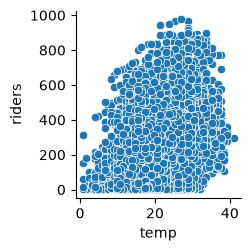

In [15]:
# plot a sns.pairplot for temp against 'riders' column

sns.pairplot(data=bike, x_vars='temp',y_vars='riders')

### Step 1: Assemble our predictor variables (X) and our target (y) 

In [16]:
# X to be temp, y is our target which is riders
X=bike[['temp']]
y=bike['riders']


# Ensure that X and y are the same length
# check X type , shape
# check y type, shape
print(type(X), X.shape)
print(type(y), y.shape)


<class 'pandas.DataFrame'> (10886, 1)
<class 'pandas.Series'> (10886,)


### Step 2: Instantiate the model

In [17]:
# Instantiate the estimator
lr = LinearRegression()


### Step 3: Fit the model

In [18]:
# Fit the estimator (train your model)
lr.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['temp']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.046
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [19]:
# check .intercept_ value

lr.intercept_

np.float64(6.046212959616412)

In [20]:
# check .coef_ value

lr.coef_

array([9.17054048])

### Step 4: Use the estimator to make predictions

In [21]:
# Use the estimator to make predictions
# save it as a column in your dataframe table as y_pred

bike['y_pred']=lr.predict(X)

In [22]:
# create a column called y_pred_equ and do the calculation of prediction manually
bike['y_pred_equ']=lr.intercept_ + (lr.coef_*bike['temp'])



In [23]:
# show the head of the dataframe and compare the results of the two columns
# are they similiar?
bike.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,riders,y_pred,y_pred_equ
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16,96.284331,96.284331
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40,88.764488,88.764488
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32,88.764488,88.764488
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13,96.284331,96.284331
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1,96.284331,96.284331


### Step 4: Evaluate the Predictions using the appropriate metric

In [24]:
# Evaluate the predictions using the appropriate metric

# show R-Squared metrics using .score(X,y)
print("R-Squared is:" , lr.score(X,y))

# RMSE using sqrt(mean_squared_error(y,y_hat))
print("RMSE is:", np.sqrt(mean_squared_error(y,bike['y_pred'])))


R-Squared is: 0.15559367802794855
RMSE is: 166.44886243326746


# Multiple Linear Regression in `sklearn`
---
We've built a simple linear regression, one using only one feature, and it's pretty useful. But is it likely that only one feature is going be accurate?

<a id="adding-more-features-to-the-model"></a>
### Adding More Features to the Model

In the previous example, one variable explained the variance of another; however, more often, we will need multiple variables. 

- For example, a house's price may be best measured by square feet, but a lot of other variables play a vital role: bedrooms, bathrooms, location, appliances, etc. 

- For a linear regression, we want these variables to be largely independent of one another, but all of them should help explain the y variable.

We'll work with bikeshare data to showcase what this means and to explain a concept called multicollinearity.

#### Explore more features.

In [25]:
# show the head

bike.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,riders,y_pred,y_pred_equ
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16,96.284331,96.284331
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40,88.764488,88.764488
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32,88.764488,88.764488
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13,96.284331,96.284331
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1,96.284331,96.284331


In [26]:
# check correlation again using df.corr() with the 'count' column only

bike.corr()[['riders']]


,riders
datetime,0.310187
season,0.163439
holiday,-0.005393
workingday,0.011594
weather,-0.128655
temp,0.394454
atemp,0.389784
humidity,-0.317371
windspeed,0.101369
riders,1.000000


<Axes: >

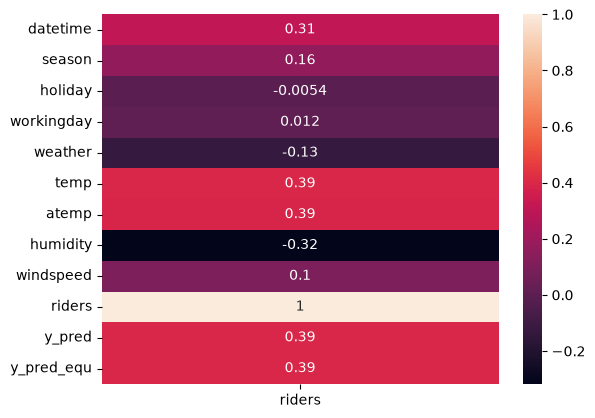

In [28]:
# check correlation again using sns.headmap(df.corr())
# include annot=True

sns.heatmap(bike.corr()[['riders']],annot=True)

In [29]:
# Create feature_col variables for 'season','temp','atemp','humidity','weather' columns

feature_col = ['season','temp','atemp','humidity','weather']

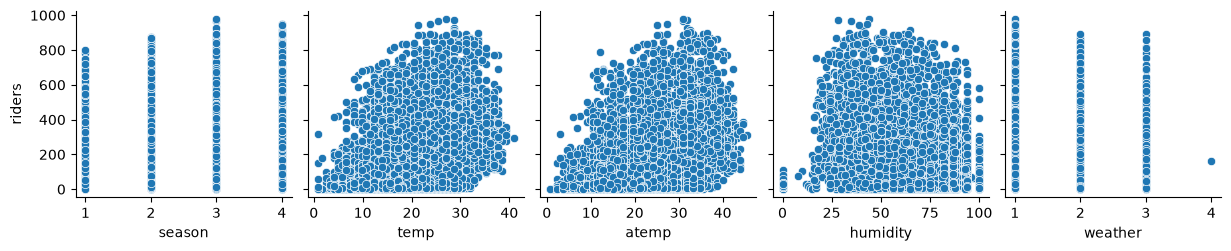

In [30]:
# check linear relationship using sns.pairplot between the selected features and the 'riders' target column

sns.pairplot(bike, x_vars=feature_col, y_vars='riders')

In [31]:
# step 2: Create a feature matrix call it X2 that contains the features columns
#         Create a target y as the 'riders' column. Note: as a series
X2= bike[feature_col]
y=bike['riders']

# Show the head of X2
X2.head()

,season,temp,atemp,humidity,weather
0,1,9.84,14.395,81,1
1,1,9.02,13.635,80,1
2,1,9.02,13.635,80,1
3,1,9.84,14.395,75,1
4,1,9.84,14.395,75,1


In [32]:
# show the head of y column
y.head()

0    16
1    40
2    32
3    13
4     1
Name: riders, dtype: int64

In [33]:
# step 3: Ensure that X and y are the same length
# check X2 type , shape
# check y2 type , shape

print (type(X2),X2.shape)
print (type(y),y.shape)


<class 'pandas.DataFrame'> (10886, 5)
<class 'pandas.Series'> (10886,)


In [34]:
# step 4: Instantiate the estimator as lr2
lr2 = LinearRegression()


In [35]:
# step 5: Fit the estimator (train your model) using X2 and y
lr2.fit(X2,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[22.33, 2.65, 4.87,-3.17, 7.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['season','temp','atemp','humidity','weather']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [36]:
# step 6: Use the estimator to make predictions
# create a column y_pred_mlt to save the prediction results
bike['y_pred_mlt'] = lr2.predict(X2)

# show bike head
bike.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,riders,y_pred,y_pred_equ,y_pred_mlt
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16,96.284331,96.284331,21.626167
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40,88.764488,88.764488,18.921829
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32,88.764488,88.764488,18.921829
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13,96.284331,96.284331,40.645197
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1,96.284331,96.284331,40.645197


In [37]:
# step 8: Evaluate the predictions using the appropriate metric

#R-Squared metrics .score(X2,y)
print("R-Squared is:" , lr2.score(X2,y))

# RMSE
print ("RMSE is:" , np.sqrt(mean_squared_error(y, bike['y_pred_mlt'])))

R-Squared is: 0.2598215881956899
RMSE is: 155.8379765026408


In [38]:
# check intercept

lr2.intercept_

np.float64(152.47810701943413)

In [39]:
# check coef

lr2.coef_

array([22.32958394,  2.64719803,  4.87299197, -3.1698383 ,  7.38023014])

In [40]:
# what are the feature columns that you selected

feature_col

['season', 'temp', 'atemp', 'humidity', 'weather']

In [41]:
# check coef (Pair the feature names with the coefficients.)
list(zip(feature_col,lr2.coef_))


[('season', np.float64(22.329583935871934)),
 ('temp', np.float64(2.6471980323952042)),
 ('atemp', np.float64(4.872991968332664)),
 ('humidity', np.float64(-3.16983829658077)),
 ('weather', np.float64(7.380230143705427))]

Interpreting the coefficients:

- Holding all other features fixed, a 1-unit increase in temperature is associated with a rental increase of 2.64 bikes.
- Holding all other features fixed, a 1-unit increase in atemperature (feels like) is associated with a rental increase of 4.87 bikes.
- Holding all other features fixed, a 1-unit increase in season is associated with a rental increase of 22.3 bikes.
- Holding all other features fixed, a 1-unit increase in humidity is associated with a rental decrease of 3.16 bikes.
- Holding all other features fixed, a 1-unit increase in weather is associated with a rental increase of 7.38 bikes.


Does anything look incorrect and does not reflect reality?

<a id="what-is-multicollinearity"></a>
## What Is Multicollinearity?
---

Multicollinearity happens when two or more features are highly correlated with each other. The problem is that due to the high correlation, it's hard to clarify which feature has what kind of effect on the outcome. In other words, the features mask each other. 

There is a second related issue called variance inflation where including correlated features increases the variability of our model and p-values by widening the standard errors. This can be measured with the variance inflation factor, which we will not cover here.

#### With the bikeshare data, let's compare two data points: actual temperature and "feel" temperature

In [42]:
# show the correlation of all feature_col

bike[feature_col].corr()

,season,temp,atemp,humidity,weather
season,1.000000,0.258689,0.264744,0.190610,0.008879
temp,0.258689,1.000000,0.984948,-0.064949,-0.055035
atemp,0.264744,0.984948,1.000000,-0.043536,-0.055376
humidity,0.190610,-0.064949,-0.043536,1.000000,0.406244
weather,0.008879,-0.055035,-0.055376,0.406244,1.000000


### Plot actual vs. predicted & residual vs. predicted

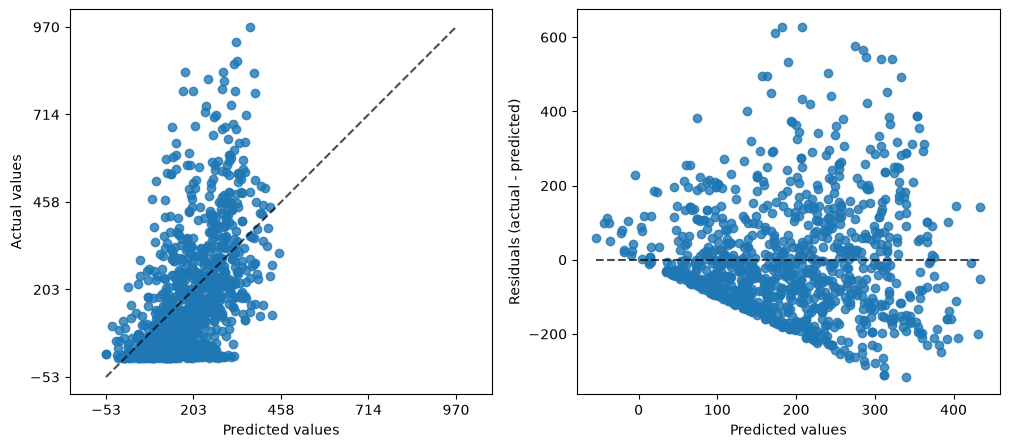

In [43]:
from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
PredictionErrorDisplay.from_estimator(lr2, X2, y, kind="actual_vs_predicted", ax=axs[0])
PredictionErrorDisplay.from_estimator(lr2, X2, y, kind="residual_vs_predicted", ax=axs[1]);


<a id='assumptions'></a>

## Assumptions of Multiple Linear Regression (MLR)

---

Like SLR, there are assumptions associated with MLR. Luckily, they're quite similar to the SLR assumptions.

1. **Linearity:** $Y$ must have an approximately linear relationship with each independent $X_i$.
2. **Independence:** Errors (residuals) $\varepsilon_i$ and $\varepsilon_j$ must be independent of one another for any $i \ne j$.
    - A classic violation is time-series data (e.g., stock prices day-by-day), where today's price is highly dependent on yesterday's price
3. **Normality:** The errors (residuals) follow a Normal distribution with mean 0.
4. **Equality of Variances**: The errors (residuals) should have a roughly consistent pattern, regardless of the value of the $X_i$ predictors. (There should be no discernable relationship between the $X$ predictors and the residuals.)
5. **Independence of Predictors**: The independent variables $X_i$ and $X_j$ must be independent of one another for any $i \ne j$.

The mnemonic `LINEI` is a useful way to remember these five assumptions.

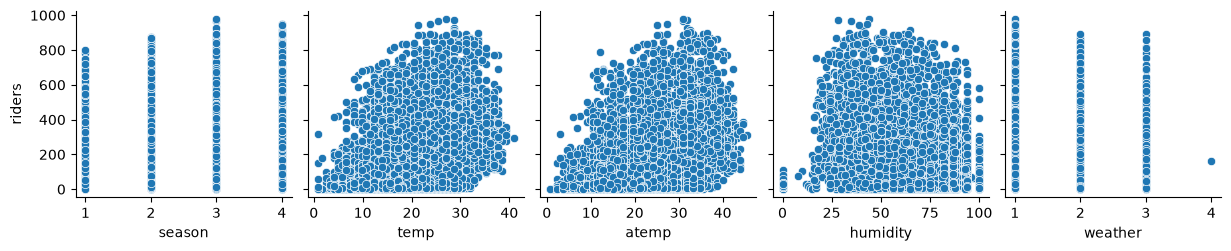

In [44]:
# L:
sns.pairplot(bike, x_vars=feature_col, y_vars='riders')

In [46]:
# I:
# assumed
# although this is probabily violated since this is time-series data

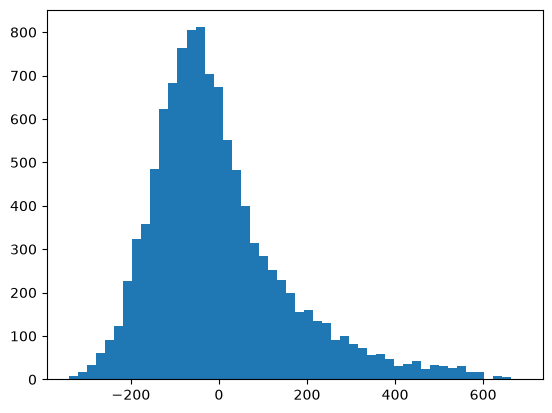

In [45]:
# N:
resids = y - bike['y_pred_mlt']
plt.hist(resids, bins=50);

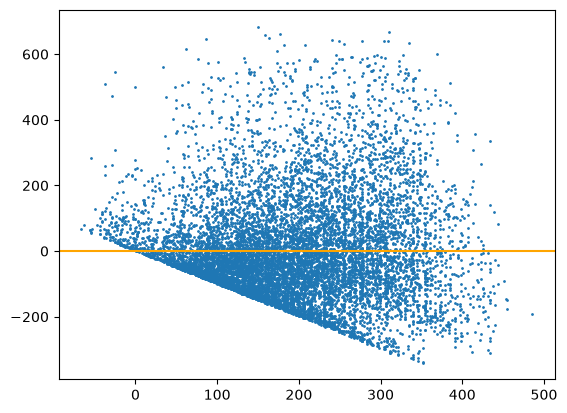

In [46]:
# E:
plt.scatter(bike['y_pred_mlt'], resids, s=1)
plt.axhline(0, color="orange");

In [47]:
# M/I:
# High Correlation between temp and atemp
X2.corr()

,season,temp,atemp,humidity,weather
season,1.000000,0.258689,0.264744,0.190610,0.008879
temp,0.258689,1.000000,0.984948,-0.064949,-0.055035
atemp,0.264744,0.984948,1.000000,-0.043536,-0.055376
humidity,0.190610,-0.064949,-0.043536,1.000000,0.406244
weather,0.008879,-0.055035,-0.055376,0.406244,1.000000


## Extra Reading #1: The Curse of Dimensionality
It turns out that the more variables we add to our model, the better it is. Actually, it doesn't even matter what this variable was, that will always be true. Even if it's completely irrelevant. That is, if we added the following variables to our model:

* Is there a sunspot on this day?
* The closing stock price of Apple that day.
* Whether or not Guy Fieri had pancakes for breakfast that day.
* A column of completely random standard normal variables

Our model is **guaranteed** to get better. But it isn't _really_ a better model, right? It turns out, we're modeling **noise**, not **signal**. We'll talk more about this phenomenon later.

## Extra Reading #2: Matrix Notation and Solution
Recall our matrix notations:

$$
\mathbf{y} = \begin{bmatrix} y_1 & y_2 & \cdots & y_n \end{bmatrix}^T
$$

$$
\beta = \begin{bmatrix} \beta_0 & \beta_1 & \cdots & \beta_p \end{bmatrix}^T
$$

$$
\mathbf{X} = \begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p} \\
1 & x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & x_{n1} & x_{n2} & \cdots & x_{np} \\ 
\end{bmatrix}
$$

It then works out we can write our model as:

$$\mathbf{y} = \mathbf{X}\beta + \varepsilon$$

Which makes our solution:

$$\mathbf{\hat{y}} = \mathbf{X}\hat{\beta}$$

where

$$\hat{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

Look confusing? It is! It haunts the dreams of second-year grad students. But it's not _too_ mysterious. If you'd like to understand it better, check out the **numpy ladder challenge**. Really, the take away here is singular:

### **The solution to our problem exists in closed form and can be computed by simple matrix multiplication.**